# Model Development

In this notebook we:

- train machine learning models
- evaluate performance
- compare models
- analyze classification quality
- save trained artifacts

This phase converts engineered NLP features
into predictive machine learning systems.

In [70]:
import os

import joblib

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report,

    confusion_matrix,

    ConfusionMatrixDisplay
)

In [6]:
DATA_PATH = (

    "../data/interim/"
    "emails_cleaned.csv"
)

df = pd.read_csv(

    DATA_PATH,

    keep_default_na=False
)

print(

    df.shape
)

df.head()

(5755, 10)


,label,subject,from,to,date,content_type,body,email_length,clean_text,clean_text_length
0,ham,Re: New Sequences Window,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700","text/plain; charset=""us-ascii""","Date: Wed, 21 Aug 2002 10:54:46 -0500\n...",1598,date wed aug chri garrigu messageid cant repro...,808
1,ham,[zzzzteana] RE: Alexander,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100","text/plain; charset=""US-ASCII""","Martin A posted:\nTassos Papadopoulos, the Gre...",894,martin post tasso papadopoulo greek sculptor b...,399
2,ham,[zzzzteana] Moscow bomber,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100","text/plain; charset=""US-ASCII""",Man Threatens Explosion In Moscow \n\nThursday...,1746,man threaten explos moscow thursday august pm ...,902
3,ham,[IRR] Klez: The Virus That Won't Die,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,"Thu, 22 Aug 2002 09:15:25 -0400","text/plain; charset=""us-ascii""",Klez: The Virus That Won't Die\n \nAlready the...,1125,klez viru wont die alreadi prolif viru ever kl...,590
4,ham,Re: [zzzzteana] Nothing like mama used to make,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100","text/plain; charset=""US-ASCII""","> in adding cream to spaghetti carbonara, whi...",1047,ad cream spaghetti carbonara effect pasta make...,464


In [7]:
df["label"].value_counts()

label
ham     3895
spam    1860
Name: count, dtype: int64

In [8]:
vectorizer = joblib.load(

    "../artifacts/tfidf_vectorizer.pkl"
)

print(

    type(vectorizer)
)

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [9]:
label_encoder = joblib.load(

    "../artifacts/label_encoder.pkl"
)

print(

    label_encoder.classes_
)

['ham' 'spam']


In [10]:
X = df["clean_text"]

y = df["label"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(

    "X_train:",
    X_train.shape
)

print(

    "X_test:",
    X_test.shape
)

X_train: (4604,)
X_test: (1151,)


In [12]:
X_train_tfidf = vectorizer.transform(

    X_train
)

X_test_tfidf = vectorizer.transform(

    X_test
)

print(

    X_train_tfidf.shape
)

print(

    X_test_tfidf.shape
)

(4604, 5000)
(1151, 5000)


# Why We Use transform Instead of fit_transform

The TF-IDF vectorizer was already trained during preprocessing.

We only use:

- transform()

to ensure:
- same vocabulary
- same feature space
- no data leakage

This is critical in real ML systems.

In [13]:
nb_model = MultinomialNB()

nb_model.fit(

    X_train_tfidf,
    y_train
)

print(

    "Naive Bayes model trained successfully."
)

Naive Bayes model trained successfully.


In [14]:
y_pred = nb_model.predict(

    X_test_tfidf
)

y_pred[:10]

array(['ham', 'spam', 'ham', 'spam', 'spam', 'ham', 'ham', 'spam', 'ham',
       'ham'], dtype='<U4')

In [15]:
accuracy = accuracy_score(

    y_test,
    y_pred
)

precision = precision_score(

    y_test,
    y_pred,

    pos_label="spam"
)

recall = recall_score(

    y_test,
    y_pred,

    pos_label="spam"
)

f1 = f1_score(

    y_test,
    y_pred,

    pos_label="spam"
)

print(

    f"Accuracy : {accuracy:.4f}"
)

print(

    f"Precision: {precision:.4f}"
)

print(

    f"Recall   : {recall:.4f}"
)

print(

    f"F1 Score : {f1:.4f}"
)

Accuracy : 0.9861
Precision: 0.9972
Recall   : 0.9597
F1 Score : 0.9781


In [16]:
print(

    classification_report(

        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       779
        spam       1.00      0.96      0.98       372

    accuracy                           0.99      1151
   macro avg       0.99      0.98      0.98      1151
weighted avg       0.99      0.99      0.99      1151



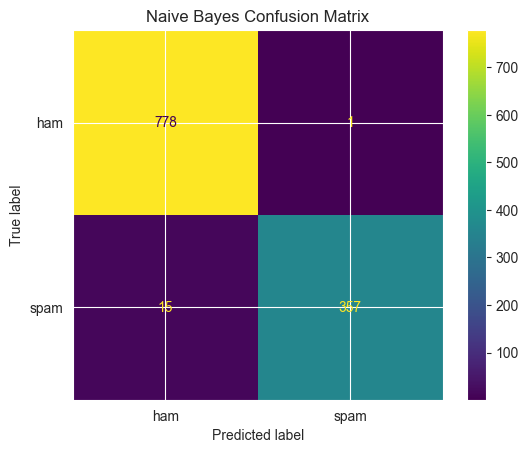

In [17]:
cm = confusion_matrix(

    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=label_encoder.classes_
)

disp.plot()

plt.title(

    "Naive Bayes Confusion Matrix"
)

plt.show()

# Why Confusion Matrix Matters

Accuracy alone is not enough in spam detection.

Important cases:

- False Positive:
    Ham email classified as spam

- False Negative:
    Spam email classified as ham

False negatives are especially dangerous because
malicious emails may reach users.

In [20]:
y_proba = nb_model.predict_proba(

    X_test_tfidf
)

print(

    y_proba[:5]
)

[[9.88742923e-01 1.12570767e-02]
 [5.53067246e-05 9.99944693e-01]
 [9.97400037e-01 2.59996268e-03]
 [2.86462766e-01 7.13537234e-01]
 [6.39498279e-02 9.36050172e-01]]


In [21]:
spam_probabilities = y_proba[:, 1]

print(

    spam_probabilities[:10]
)

[1.12570767e-02 9.99944693e-01 2.59996268e-03 7.13537234e-01
 9.36050172e-01 2.75844181e-03 7.39137420e-05 9.98596229e-01
 5.74795036e-04 1.33031961e-02]


In [22]:
results_df = pd.DataFrame({

    "text": X_test,

    "actual": y_test,

    "predicted": y_pred,

    "spam_probability": spam_probabilities
})

results_df.head()

,text,actual,predicted,spam_probability
895,john hall wrote wasnt gloat horror file cours ...,ham,ham,0.011257
5345,free person busi grant qualifi least free gran...,spam,spam,0.999945
3777,hello peopl new sa problem run sa home person ...,ham,ham,0.002600
5670,sihd ooeuѱmsiqnoūhlk m½ܡh goܡhh q֦ۤvʒܡhhh háii...,spam,spam,0.713537
4935,find chattingemail hour spous cheat onlin kid ...,spam,spam,0.936050


In [23]:
def get_threat_level(probability):

    """
    Converts spam probability
    into threat levels.

    Args:
        probability (float):
            Spam probability.

    Returns:
        str:
            Threat level.
    """

    if probability >= 0.90:

        return "HIGH"

    elif probability >= 0.60:

        return "MEDIUM"

    else:

        return "LOW"

In [24]:
results_df["threat_level"] = (

    results_df["spam_probability"]

    .apply(get_threat_level)
)

results_df.head()

,text,actual,predicted,spam_probability,threat_level
895,john hall wrote wasnt gloat horror file cours ...,ham,ham,0.011257,LOW
5345,free person busi grant qualifi least free gran...,spam,spam,0.999945,HIGH
3777,hello peopl new sa problem run sa home person ...,ham,ham,0.002600,LOW
5670,sihd ooeuѱmsiqnoūhlk m½ܡh goܡhh q֦ۤvʒܡhhh háii...,spam,spam,0.713537,MEDIUM
4935,find chattingemail hour spous cheat onlin kid ...,spam,spam,0.936050,HIGH


In [25]:
false_positives = results_df[

    (results_df["actual"] == "ham")
    &
    (results_df["predicted"] == "spam")
]

print(

    false_positives.shape
)

false_positives.head()

(1, 5)


,text,actual,predicted,spam_probability,threat_level
3002,howdi possess follow appl toner cartridg ga la...,ham,spam,0.834114,MEDIUM


In [26]:
false_negatives = results_df[

    (results_df["actual"] == "spam")
    &
    (results_df["predicted"] == "ham")
]

print(

    false_negatives.shape
)

false_negatives.head()

(15, 5)


,text,actual,predicted,spam_probability,threat_level
4783,origin messag rathcairn automail script automa...,spam,ham,0.035582,LOW
5430,մθ մθ ̺ʈ ʹٱ ̵ ֽθ ÿθ ȭϸ ȭǵ ũż 湮ͻø 帳θ ˼մθ ȸ̹ƿ ű...,spam,ham,0.340675,LOW
5153,meta contenttext charsetkoi irish linux user g...,spam,ham,0.003126,LOW
4161,introduct sell backup cd known warez cd backup...,spam,ham,0.368771,LOW
4142,qpߤl qѵnbwanoơc گǧaoˤlnboѥΰƶ qnաgmihaԣh ҥhaߤln...,spam,ham,0.323197,LOW


In [18]:
os.makedirs(

    "../models",

    exist_ok=True
)

In [19]:
model_path = (

    "../models/"
    "naive_bayes_model.pkl"
)

joblib.dump(

    nb_model,
    model_path
)

print(

    f"Model saved to:\n{model_path}"
)

Model saved to:
../models/naive_bayes_model.pkl


# Error Analysis Summary

The model achieved very strong performance overall.

However, some spam emails were misclassified as ham.

Observed challenges:

- obfuscated unicode spam
- encoded/non-English text
- spam emails with ham-like wording
- noisy formatting

This highlights an important real-world ML challenge:

Attackers intentionally modify spam patterns
to evade detection systems.

Future improvements may include:

- character-level models
- advanced NLP embeddings
- metadata features
- URL-based features
- HTML structure analysis

# Logistic Regression Model

Logistic Regression is one of the most effective
baseline models for NLP classification tasks.

Advantages:
- handles sparse TF-IDF vectors well
- strong generalization
- interpretable probabilities
- widely used in production NLP systems

In [27]:
lr_model = LogisticRegression(

    max_iter=1000,

    random_state=42
)

lr_model.fit(

    X_train_tfidf,
    y_train
)

print(

    "Logistic Regression model trained successfully."
)

Logistic Regression model trained successfully.


In [28]:
lr_y_pred = lr_model.predict(

    X_test_tfidf
)

lr_y_pred[:10]

array(['ham', 'spam', 'ham', 'spam', 'spam', 'ham', 'ham', 'spam', 'ham',
       'ham'], dtype=object)

In [29]:
lr_accuracy = accuracy_score(

    y_test,
    lr_y_pred
)

lr_precision = precision_score(

    y_test,
    lr_y_pred,

    pos_label="spam"
)

lr_recall = recall_score(

    y_test,
    lr_y_pred,

    pos_label="spam"
)

lr_f1 = f1_score(

    y_test,
    lr_y_pred,

    pos_label="spam"
)

print(

    f"Accuracy : {lr_accuracy:.4f}"
)

print(

    f"Precision: {lr_precision:.4f}"
)

print(

    f"Recall   : {lr_recall:.4f}"
)

print(

    f"F1 Score : {lr_f1:.4f}"
)

Accuracy : 0.9818
Precision: 1.0000
Recall   : 0.9435
F1 Score : 0.9710


In [30]:
print(

    classification_report(

        y_test,
        lr_y_pred
    )
)

              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       779
        spam       1.00      0.94      0.97       372

    accuracy                           0.98      1151
   macro avg       0.99      0.97      0.98      1151
weighted avg       0.98      0.98      0.98      1151



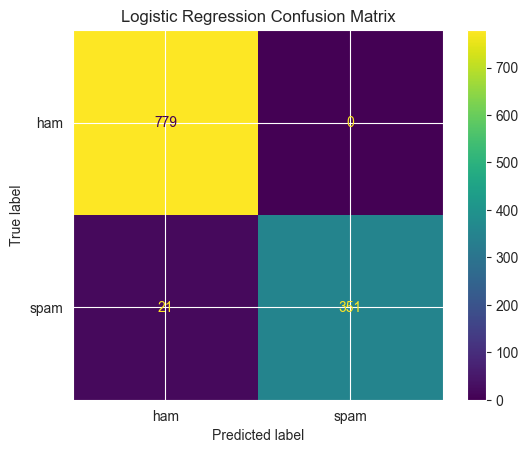

In [31]:
lr_cm = confusion_matrix(

    y_test,
    lr_y_pred
)

lr_disp = ConfusionMatrixDisplay(

    confusion_matrix=lr_cm,

    display_labels=label_encoder.classes_
)

lr_disp.plot()

plt.title(

    "Logistic Regression Confusion Matrix"
)

plt.show()

In [32]:
lr_y_proba = lr_model.predict_proba(

    X_test_tfidf
)

lr_spam_probabilities = lr_y_proba[:, 1]

lr_spam_probabilities[:10]

array([0.04594291, 0.95622928, 0.04836614, 0.59043061, 0.86499506,
       0.02948995, 0.01598359, 0.93411647, 0.02774295, 0.05630361])

In [33]:
lr_model_path = (

    "../models/"
    "logistic_regression_model.pkl"
)

joblib.dump(

    lr_model,
    lr_model_path
)

print(

    f"Model saved to:\n{lr_model_path}"
)

Model saved to:
../models/logistic_regression_model.pkl


In [34]:
# =========================================================
# DECISION TREE MODEL
# =========================================================

dt_model = DecisionTreeClassifier(

    max_depth=30,

    min_samples_split=5,

    random_state=42
)

dt_model.fit(

    X_train_tfidf,
    y_train
)

print(

    "Decision Tree model trained successfully."
)

Decision Tree model trained successfully.


In [35]:
# =========================================================
# DECISION TREE PREDICTIONS
# =========================================================

dt_y_pred = dt_model.predict(

    X_test_tfidf
)

dt_y_pred[:10]

array(['ham', 'spam', 'ham', 'spam', 'spam', 'ham', 'ham', 'spam', 'ham',
       'ham'], dtype=object)

In [36]:
# =========================================================
# DECISION TREE METRICS
# =========================================================

dt_accuracy = accuracy_score(

    y_test,
    dt_y_pred
)

dt_precision = precision_score(

    y_test,
    dt_y_pred,

    pos_label="spam"
)

dt_recall = recall_score(

    y_test,
    dt_y_pred,

    pos_label="spam"
)

dt_f1 = f1_score(

    y_test,
    dt_y_pred,

    pos_label="spam"
)

print(

    f"Accuracy : {dt_accuracy:.4f}"
)

print(

    f"Precision: {dt_precision:.4f}"
)

print(

    f"Recall   : {dt_recall:.4f}"
)

print(

    f"F1 Score : {dt_f1:.4f}"
)

Accuracy : 0.9296
Precision: 0.9076
Recall   : 0.8710
F1 Score : 0.8889


In [37]:
# =========================================================
# DECISION TREE CLASSIFICATION REPORT
# =========================================================

print(

    classification_report(

        y_test,
        dt_y_pred
    )
)

              precision    recall  f1-score   support

         ham       0.94      0.96      0.95       779
        spam       0.91      0.87      0.89       372

    accuracy                           0.93      1151
   macro avg       0.92      0.91      0.92      1151
weighted avg       0.93      0.93      0.93      1151



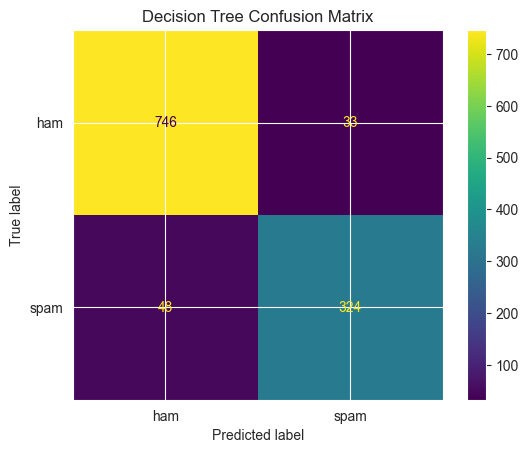

In [38]:
# =========================================================
# DECISION TREE CONFUSION MATRIX
# =========================================================

dt_cm = confusion_matrix(

    y_test,
    dt_y_pred
)

dt_disp = ConfusionMatrixDisplay(

    confusion_matrix=dt_cm,

    display_labels=label_encoder.classes_
)

dt_disp.plot()

plt.title(

    "Decision Tree Confusion Matrix"
)

plt.show()

In [39]:
# =========================================================
# SAVE DECISION TREE MODEL
# =========================================================

dt_model_path = (

    "../models/"
    "decision_tree_model.pkl"
)

joblib.dump(

    dt_model,
    dt_model_path
)

print(

    f"Model saved to:\n{dt_model_path}"
)

Model saved to:
../models/decision_tree_model.pkl


In [41]:
# =========================================================
# RANDOM FOREST MODEL
# =========================================================

rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=30,

    min_samples_split=5,

    random_state=42,

    n_jobs=-1
)

rf_model.fit(

    X_train_tfidf,
    y_train
)

print(

    "Random Forest model trained successfully."
)

Random Forest model trained successfully.


In [42]:
# =========================================================
# RANDOM FOREST PREDICTIONS
# =========================================================

rf_y_pred = rf_model.predict(

    X_test_tfidf
)

rf_y_pred[:10]

array(['ham', 'spam', 'ham', 'ham', 'spam', 'ham', 'ham', 'spam', 'ham',
       'ham'], dtype=object)

In [43]:
# =========================================================
# RANDOM FOREST METRICS
# =========================================================

rf_accuracy = accuracy_score(

    y_test,
    rf_y_pred
)

rf_precision = precision_score(

    y_test,
    rf_y_pred,

    pos_label="spam"
)

rf_recall = recall_score(

    y_test,
    rf_y_pred,

    pos_label="spam"
)

rf_f1 = f1_score(

    y_test,
    rf_y_pred,

    pos_label="spam"
)

print(

    f"Accuracy : {rf_accuracy:.4f}"
)

print(

    f"Precision: {rf_precision:.4f}"
)

print(

    f"Recall   : {rf_recall:.4f}"
)

print(

    f"F1 Score : {rf_f1:.4f}"
)

Accuracy : 0.9713
Precision: 1.0000
Recall   : 0.9113
F1 Score : 0.9536


In [44]:
# =========================================================
# RANDOM FOREST CLASSIFICATION REPORT
# =========================================================

print(

    classification_report(

        y_test,
        rf_y_pred
    )
)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       779
        spam       1.00      0.91      0.95       372

    accuracy                           0.97      1151
   macro avg       0.98      0.96      0.97      1151
weighted avg       0.97      0.97      0.97      1151



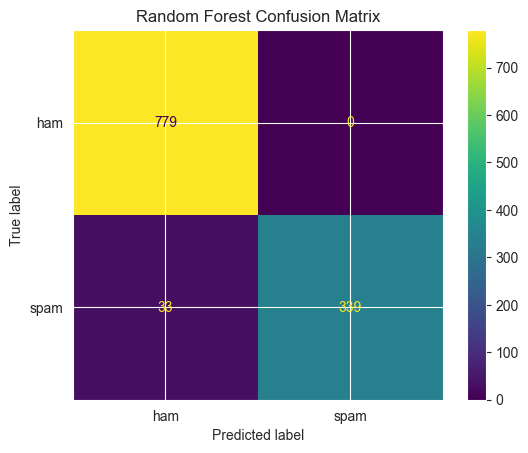

In [45]:
# =========================================================
# RANDOM FOREST CONFUSION MATRIX
# =========================================================

rf_cm = confusion_matrix(

    y_test,
    rf_y_pred
)

rf_disp = ConfusionMatrixDisplay(

    confusion_matrix=rf_cm,

    display_labels=label_encoder.classes_
)

rf_disp.plot()

plt.title(

    "Random Forest Confusion Matrix"
)

plt.show()

In [46]:
# =========================================================
# RANDOM FOREST PROBABILITIES
# =========================================================

rf_y_proba = rf_model.predict_proba(

    X_test_tfidf
)

rf_spam_probabilities = rf_y_proba[:, 1]

rf_spam_probabilities[:10]

array([0.04679745, 0.99145671, 0.14147385, 0.14500475, 0.94218189,
       0.03307088, 0.10319156, 0.94253215, 0.04242609, 0.0747043 ])

In [47]:
# =========================================================
# SAVE RANDOM FOREST MODEL
# =========================================================

rf_model_path = (

    "../models/"
    "random_forest_model.pkl"
)

joblib.dump(

    rf_model,
    rf_model_path
)

print(

    f"Model saved to:\n{rf_model_path}"
)

Model saved to:
../models/random_forest_model.pkl


In [61]:
# =========================================================
# LABEL ENCODING FOR XGBOOST
# =========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label_encoded"] = (

    label_encoder.fit_transform(
        df["label"]
    )
)

df[

    [
        "label",
        "label_encoded"
    ]

].head()

,label,label_encoded
0,ham,0
1,ham,0
2,ham,0
3,ham,0
4,ham,0


In [66]:
# =========================================================
# DEFINE FEATURES AND TARGET FOR XGBOOST
# =========================================================

X_xgb = df["clean_text"]

y_xgb = df["label_encoded"]

print(

    y_xgb.unique()
)

[0 1]


In [68]:
# =========================================================
# TRAIN TEST SPLIT FOR XGBOOST
# =========================================================

(
    X_train_xgb,
    X_test_xgb,

    y_train_xgb,
    y_test_xgb

) = train_test_split(

    X_xgb,
    y_xgb,

    test_size=0.2,

    random_state=42,

    stratify=y_xgb
)

print(

    y_train_xgb[:5]
)

1487    0
1018    0
1964    0
545     0
2965    0
Name: label_encoded, dtype: int64


In [69]:
# =========================================================
# TF-IDF TRANSFORM FOR XGBOOST
# =========================================================

X_train_tfidf_xgb = vectorizer.transform(

    X_train_xgb
)

X_test_tfidf_xgb = vectorizer.transform(

    X_test_xgb
)

print(

    X_train_tfidf_xgb.shape
)

print(

    X_test_tfidf_xgb.shape
)

(4604, 5000)
(1151, 5000)


In [71]:
# =========================================================
# XGBOOST MODEL
# =========================================================

xgb_model = XGBClassifier(

    n_estimators=100,

    max_depth=6,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

xgb_model.fit(

    X_train_tfidf_xgb,
    y_train_xgb
)

print(

    "XGBoost model trained successfully."
)

XGBoost model trained successfully.


In [72]:
# =========================================================
# XGBOOST PREDICTIONS
# =========================================================

xgb_y_pred = xgb_model.predict(

    X_test_tfidf_xgb
)

xgb_y_pred[:10]

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 0])

In [73]:
# =========================================================
# XGBOOST METRICS
# =========================================================

xgb_accuracy = accuracy_score(

    y_test_xgb,
    xgb_y_pred
)

xgb_precision = precision_score(

    y_test_xgb,
    xgb_y_pred
)

xgb_recall = recall_score(

    y_test_xgb,
    xgb_y_pred
)

xgb_f1 = f1_score(

    y_test_xgb,
    xgb_y_pred
)

print(

    f"Accuracy : {xgb_accuracy:.4f}"
)

print(

    f"Precision: {xgb_precision:.4f}"
)

print(

    f"Recall   : {xgb_recall:.4f}"
)

print(

    f"F1 Score : {xgb_f1:.4f}"
)

Accuracy : 0.9713
Precision: 0.9857
Recall   : 0.9247
F1 Score : 0.9542


In [74]:
# =========================================================
# XGBOOST CLASSIFICATION REPORT
# =========================================================

print(

    classification_report(

        y_test_xgb,
        xgb_y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       779
           1       0.99      0.92      0.95       372

    accuracy                           0.97      1151
   macro avg       0.98      0.96      0.97      1151
weighted avg       0.97      0.97      0.97      1151



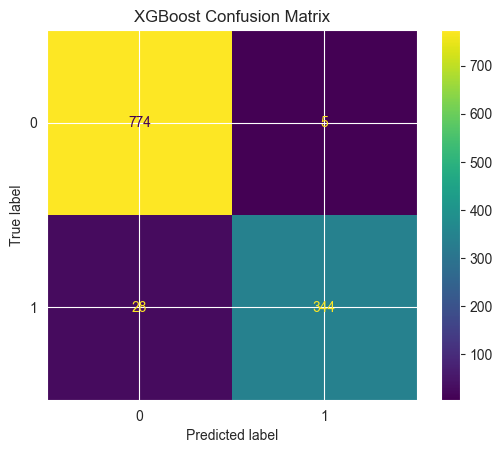

In [75]:
# =========================================================
# XGBOOST CONFUSION MATRIX
# =========================================================

xgb_cm = confusion_matrix(

    y_test_xgb,
    xgb_y_pred
)

xgb_disp = ConfusionMatrixDisplay(

    confusion_matrix=xgb_cm
)

xgb_disp.plot()

plt.title(

    "XGBoost Confusion Matrix"
)

plt.show()

In [76]:
# =========================================================
# XGBOOST PROBABILITIES
# =========================================================

xgb_y_proba = xgb_model.predict_proba(

    X_test_tfidf_xgb
)

xgb_spam_probabilities = xgb_y_proba[:, 1]

xgb_spam_probabilities[:10]

array([4.0586744e-03, 9.8775870e-01, 4.7707441e-03, 5.8653039e-01,
       9.8700178e-01, 7.2346901e-04, 9.1982782e-03, 9.8989350e-01,
       2.0946774e-03, 5.1390212e-03], dtype=float32)

In [77]:
# =========================================================
# SAVE XGBOOST MODEL
# =========================================================

xgb_model_path = (

    "../models/"
    "xgboost_model.pkl"
)

joblib.dump(

    xgb_model,
    xgb_model_path
)

print(

    f"Model saved to:\n{xgb_model_path}"
)

Model saved to:
../models/xgboost_model.pkl


In [78]:
# =========================================================
# MODEL COMPARISON
# =========================================================

comparison_df = pd.DataFrame({

    "Model": [

        "Naive Bayes",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [

        accuracy,
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [

        precision,
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [

        recall,
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [

        f1,
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.986099,0.997207,0.959677,0.978082
1,Logistic Regression,0.981755,1.000000,0.943548,0.970954
2,Decision Tree,0.929626,0.907563,0.870968,0.888889
3,Random Forest,0.971329,1.000000,0.911290,0.953586
4,XGBoost,0.971329,0.985673,0.924731,0.954230


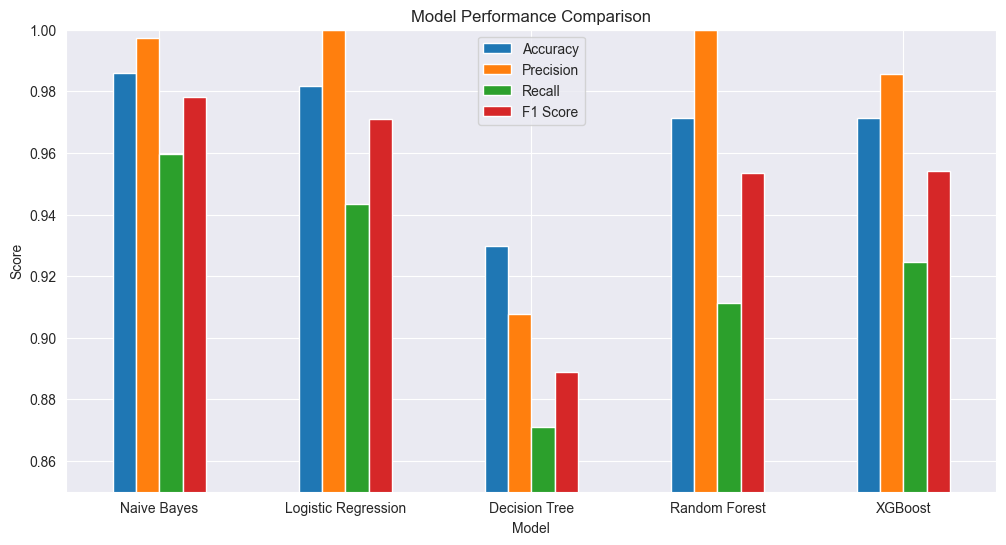

In [79]:
# =========================================================
# MODEL COMPARISON VISUALIZATION
# =========================================================

comparison_df.set_index(

    "Model"

)[

    ["Accuracy", "Precision", "Recall", "F1 Score"]

].plot(

    kind="bar",

    figsize=(12, 6)
)

plt.title(

    "Model Performance Comparison"
)

plt.ylabel(

    "Score"
)

plt.ylim(

    0.85,
    1.0
)

plt.xticks(

    rotation=0
)

plt.show()

# =========================================================
# ADVANCED HYBRID MODEL TRAINING
# =========================================================

## Objective

In this section, we train machine learning models
using the advanced hybrid feature engineering pipeline.

Unlike the baseline NLP pipeline that used only TF-IDF,
this advanced pipeline combines:

- TF-IDF textual features
- handcrafted email threat intelligence features

This creates a richer feature representation
for spam and phishing detection.

---

## Hybrid Feature Representation

The final feature matrix contains:

### NLP Features
Generated using TF-IDF:
- unigram + bigram features
- frequency-based textual importance
- sparse vector representation

### Engineered Security Features
Additional numerical threat signals:
- URL count
- exclamation count
- uppercase ratio
- HTML tag count
- special character count
- suspicious keyword count

---

## Why Hybrid Features Matter

Traditional NLP captures:
- semantic patterns
- word frequencies
- language structure

But spam detection also depends on:
- behavioral signals
- formatting abuse
- suspicious email structure
- phishing indicators

The hybrid pipeline combines both.

---

## Models Evaluated

We will retrain and compare:

1. Logistic Regression
2. Random Forest
3. XGBoost

using the advanced hybrid feature matrix.

---

## Goal

Compare advanced hybrid models against
baseline TF-IDF-only models to measure:

- accuracy improvement
- spam recall improvement
- phishing detection capability
- robustness against obfuscated spam

---

## Final Outcome

This stage demonstrates:
- advanced feature engineering
- hybrid NLP pipelines
- cybersecurity-oriented ML engineering
- production-style spam intelligence systems

# =========================================================
# ADVANCED LOGISTIC REGRESSION
# =========================================================

In this section, Logistic Regression is trained
using the advanced hybrid feature matrix.

Input features include:

- TF-IDF textual vectors
- engineered email threat intelligence features

This model is compared against the baseline
TF-IDF-only Logistic Regression model
to evaluate the impact of advanced
feature engineering.

In [110]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from scipy.sparse import hstack

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report,

    confusion_matrix,

    ConfusionMatrixDisplay
)

In [87]:
# =========================================================
# LOAD ADVANCED FEATURE ENGINEERED DATASET
# =========================================================

DATA_PATH = (

    "../data/feature_engineered/"
    "advanced_emails_feature_engineered.csv"
)

df = pd.read_csv(

    DATA_PATH,

    keep_default_na=False
)

print(

    df.shape
)

df.head()

(5755, 17)


,label,subject,from,to,date,content_type,body,email_length,clean_text,clean_text_length,url_count,exclamation_count,uppercase_ratio,html_tag_count,special_char_count,spam_keyword_count,advanced_label_encoded
0,ham,Re: New Sequences Window,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700","text/plain; charset=""us-ascii""","Date: Wed, 21 Aug 2002 10:54:46 -0500\n...",1598,date wed aug chri garrigu messageid cant repro...,808,1,0,0.028160,2,202,0,0
1,ham,[zzzzteana] RE: Alexander,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100","text/plain; charset=""US-ASCII""","Martin A posted:\nTassos Papadopoulos, the Gre...",894,martin post tasso papadopoulo greek sculptor b...,399,2,2,0.048098,0,185,2,0
2,ham,[zzzzteana] Moscow bomber,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100","text/plain; charset=""US-ASCII""",Man Threatens Explosion In Moscow \n\nThursday...,1746,man threaten explos moscow thursday august pm ...,902,2,2,0.054983,0,182,2,0
3,ham,[IRR] Klez: The Virus That Won't Die,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,"Thu, 22 Aug 2002 09:15:25 -0400","text/plain; charset=""us-ascii""",Klez: The Virus That Won't Die\n \nAlready the...,1125,klez viru wont die alreadi prolif viru ever kl...,590,2,0,0.037333,0,92,0,0
4,ham,Re: [zzzzteana] Nothing like mama used to make,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100","text/plain; charset=""US-ASCII""","> in adding cream to spaghetti carbonara, whi...",1047,ad cream spaghetti carbonara effect pasta make...,464,3,2,0.041070,0,177,2,0


In [88]:
# =========================================================
# VERIFY ADVANCED FEATURE COLUMNS
# =========================================================

df.columns

Index(['label', 'subject', 'from', 'to', 'date', 'content_type', 'body',
       'email_length', 'clean_text', 'clean_text_length', 'url_count',
       'exclamation_count', 'uppercase_ratio', 'html_tag_count',
       'special_char_count', 'spam_keyword_count', 'advanced_label_encoded'],
      dtype='str')

In [90]:
# =========================================================
# LOAD ADVANCED ARTIFACTS
# =========================================================

import joblib

advanced_vectorizer = joblib.load(

    "../artifacts/"
    "advanced_hybrid_tfidf_vectorizer.pkl"
)

advanced_scaler = joblib.load(

    "../artifacts/"
    "advanced_manual_feature_scaler.pkl"
)

advanced_label_encoder = joblib.load(

    "../artifacts/"
    "advanced_hybrid_label_encoder.pkl"
)

print(

    "Advanced artifacts loaded successfully."
)

Advanced artifacts loaded successfully.


In [91]:
# =========================================================
# RECREATE ADVANCED FEATURES
# =========================================================

advanced_text_features = df["clean_text"]

advanced_manual_features = df[

    [

        "url_count",

        "exclamation_count",

        "uppercase_ratio",

        "html_tag_count",

        "special_char_count",

        "spam_keyword_count"
    ]
]

advanced_target = df["advanced_label_encoded"]

print(

    advanced_text_features.shape
)

print(

    advanced_manual_features.shape
)

print(

    advanced_target.shape
)

(5755,)
(5755, 6)
(5755,)


In [92]:
# =========================================================
# ADVANCED TRAIN TEST SPLIT
# =========================================================

(
    X_train_text_advanced,
    X_test_text_advanced,

    X_train_manual_advanced,
    X_test_manual_advanced,

    y_train_advanced,
    y_test_advanced

) = train_test_split(

    advanced_text_features,

    advanced_manual_features,

    advanced_target,

    test_size=0.2,

    random_state=42,

    stratify=advanced_target
)

print(

    X_train_text_advanced.shape
)

print(

    X_test_text_advanced.shape
)

(4604,)
(1151,)


In [93]:
# =========================================================
# TF-IDF TRANSFORM USING LOADED VECTORIZER
# =========================================================

X_train_tfidf_advanced = (

    advanced_vectorizer.transform(

        X_train_text_advanced
    )
)

X_test_tfidf_advanced = (

    advanced_vectorizer.transform(

        X_test_text_advanced
    )
)

print(

    X_train_tfidf_advanced.shape
)

print(

    X_test_tfidf_advanced.shape
)

(4604, 5000)
(1151, 5000)


In [94]:
# =========================================================
# SCALE MANUAL FEATURES USING LOADED SCALER
# =========================================================

X_train_manual_scaled_advanced = (

    advanced_scaler.transform(

        X_train_manual_advanced
    )
)

X_test_manual_scaled_advanced = (

    advanced_scaler.transform(

        X_test_manual_advanced
    )
)

print(

    X_train_manual_scaled_advanced.shape
)

print(

    X_test_manual_scaled_advanced.shape
)

(4604, 6)
(1151, 6)


In [95]:
# =========================================================
# COMBINE ADVANCED FEATURES
# =========================================================

X_train_combined_advanced = hstack([

    X_train_tfidf_advanced,

    X_train_manual_scaled_advanced

]).tocsr()

X_test_combined_advanced = hstack([

    X_test_tfidf_advanced,

    X_test_manual_scaled_advanced

]).tocsr()

print(

    X_train_combined_advanced.shape
)

print(

    X_test_combined_advanced.shape
)

print(

    type(X_train_combined_advanced)
)

(4604, 5006)
(1151, 5006)
<class 'scipy.sparse._csr.csr_matrix'>


In [96]:
# =========================================================
# ADVANCED LOGISTIC REGRESSION MODEL
# =========================================================

advanced_lr_model = LogisticRegression(

    max_iter=1000,

    random_state=42
)

advanced_lr_model.fit(

    X_train_combined_advanced,

    y_train_advanced
)

print(

    "Advanced Logistic Regression model trained successfully."
)

Advanced Logistic Regression model trained successfully.


In [97]:
# =========================================================
# ADVANCED LOGISTIC REGRESSION PREDICTIONS
# =========================================================

advanced_lr_y_pred = advanced_lr_model.predict(

    X_test_combined_advanced
)

advanced_lr_y_pred[:10]

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 0])

In [98]:
# =========================================================
# ADVANCED LOGISTIC REGRESSION METRICS
# =========================================================

advanced_lr_accuracy = accuracy_score(

    y_test_advanced,
    advanced_lr_y_pred
)

advanced_lr_precision = precision_score(

    y_test_advanced,
    advanced_lr_y_pred
)

advanced_lr_recall = recall_score(

    y_test_advanced,
    advanced_lr_y_pred
)

advanced_lr_f1 = f1_score(

    y_test_advanced,
    advanced_lr_y_pred
)

print(

    f"Accuracy : {advanced_lr_accuracy:.4f}"
)

print(

    f"Precision: {advanced_lr_precision:.4f}"
)

print(

    f"Recall   : {advanced_lr_recall:.4f}"
)

print(

    f"F1 Score : {advanced_lr_f1:.4f}"
)

Accuracy : 0.9757
Precision: 0.9914
Recall   : 0.9328
F1 Score : 0.9612


In [99]:
# =========================================================
# ADVANCED LOGISTIC REGRESSION REPORT
# =========================================================

print(

    classification_report(

        y_test_advanced,
        advanced_lr_y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       779
           1       0.99      0.93      0.96       372

    accuracy                           0.98      1151
   macro avg       0.98      0.96      0.97      1151
weighted avg       0.98      0.98      0.98      1151



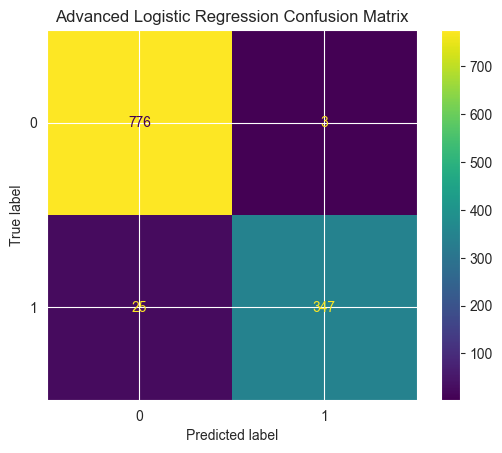

In [100]:
# =========================================================
# ADVANCED LOGISTIC REGRESSION CONFUSION MATRIX
# =========================================================

advanced_lr_cm = confusion_matrix(

    y_test_advanced,
    advanced_lr_y_pred
)

advanced_lr_disp = ConfusionMatrixDisplay(

    confusion_matrix=advanced_lr_cm
)

advanced_lr_disp.plot()

plt.title(

    "Advanced Logistic Regression Confusion Matrix"
)

plt.show()

In [101]:
# =========================================================
# SAVE ADVANCED LOGISTIC REGRESSION MODEL
# =========================================================

advanced_lr_model_path = (

    "../models/"
    "advanced_logistic_regression_model.pkl"
)

joblib.dump(

    advanced_lr_model,
    advanced_lr_model_path
)

print(

    f"Model saved to:\n{advanced_lr_model_path}"
)

Model saved to:
../models/advanced_logistic_regression_model.pkl


# =========================================================
# ADVANCED RANDOM FOREST MODEL
# =========================================================

This section trains Random Forest using:

- TF-IDF text features
- Advanced handcrafted email threat features

Goal:
Evaluate hybrid feature engineering using ensemble bagging methods.

In [104]:
# =========================================================
# ADVANCED RANDOM FOREST MODEL
# =========================================================

advanced_rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=30,

    min_samples_split=5,

    random_state=42,

    n_jobs=-1
)

advanced_rf_model.fit(

    X_train_combined_advanced,

    y_train_advanced
)

print(

    "Advanced Random Forest model trained successfully."
)

Advanced Random Forest model trained successfully.


In [105]:
# =========================================================
# ADVANCED RANDOM FOREST PREDICTIONS
# =========================================================

advanced_rf_y_pred = advanced_rf_model.predict(

    X_test_combined_advanced
)

advanced_rf_y_pred[:10]

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0])

In [106]:
# =========================================================
# ADVANCED RANDOM FOREST METRICS
# =========================================================

advanced_rf_accuracy = accuracy_score(

    y_test_advanced,
    advanced_rf_y_pred
)

advanced_rf_precision = precision_score(

    y_test_advanced,
    advanced_rf_y_pred
)

advanced_rf_recall = recall_score(

    y_test_advanced,
    advanced_rf_y_pred
)

advanced_rf_f1 = f1_score(

    y_test_advanced,
    advanced_rf_y_pred
)

print(

    f"Accuracy : {advanced_rf_accuracy:.4f}"
)

print(

    f"Precision: {advanced_rf_precision:.4f}"
)

print(

    f"Recall   : {advanced_rf_recall:.4f}"
)

print(

    f"F1 Score : {advanced_rf_f1:.4f}"
)

Accuracy : 0.9791
Precision: 0.9943
Recall   : 0.9409
F1 Score : 0.9669


In [107]:
# =========================================================
# ADVANCED RANDOM FOREST REPORT
# =========================================================

print(

    classification_report(

        y_test_advanced,
        advanced_rf_y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       779
           1       0.99      0.94      0.97       372

    accuracy                           0.98      1151
   macro avg       0.98      0.97      0.98      1151
weighted avg       0.98      0.98      0.98      1151



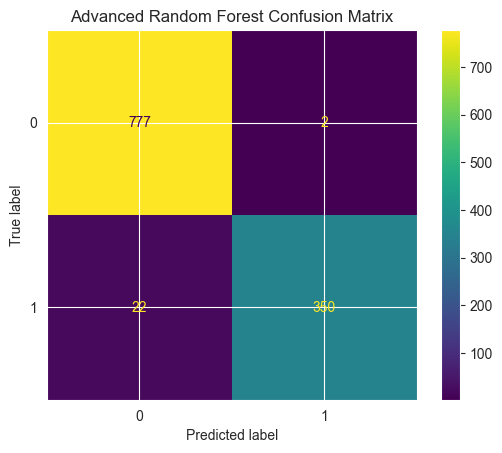

In [108]:
# =========================================================
# ADVANCED RANDOM FOREST CONFUSION MATRIX
# =========================================================

advanced_rf_cm = confusion_matrix(

    y_test_advanced,
    advanced_rf_y_pred
)

advanced_rf_disp = ConfusionMatrixDisplay(

    confusion_matrix=advanced_rf_cm
)

advanced_rf_disp.plot()

plt.title(

    "Advanced Random Forest Confusion Matrix"
)

plt.show()

In [109]:
# =========================================================
# SAVE ADVANCED RANDOM FOREST MODEL
# =========================================================

advanced_rf_model_path = (

    "../models/"
    "advanced_random_forest_model.pkl"
)

joblib.dump(

    advanced_rf_model,
    advanced_rf_model_path
)

print(

    f"Model saved to:\n{advanced_rf_model_path}"
)

Model saved to:
../models/advanced_random_forest_model.pkl


# =========================================================
# ADVANCED XGBOOST MODEL
# =========================================================

This section trains XGBoost using:

- TF-IDF text features
- Advanced handcrafted email threat features

Goal:
Evaluate boosting performance on hybrid spam detection.

In [111]:
# =========================================================
# ADVANCED XGBOOST MODEL
# =========================================================

advanced_xgb_model = XGBClassifier(

    n_estimators=100,

    max_depth=6,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

advanced_xgb_model.fit(

    X_train_combined_advanced,

    y_train_advanced
)

print(

    "Advanced XGBoost model trained successfully."
)

Advanced XGBoost model trained successfully.


In [112]:
# =========================================================
# ADVANCED XGBOOST PREDICTIONS
# =========================================================

advanced_xgb_y_pred = advanced_xgb_model.predict(

    X_test_combined_advanced
)

advanced_xgb_y_pred[:10]

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 0])

In [113]:
# =========================================================
# ADVANCED XGBOOST METRICS
# =========================================================

advanced_xgb_accuracy = accuracy_score(

    y_test_advanced,
    advanced_xgb_y_pred
)

advanced_xgb_precision = precision_score(

    y_test_advanced,
    advanced_xgb_y_pred
)

advanced_xgb_recall = recall_score(

    y_test_advanced,
    advanced_xgb_y_pred
)

advanced_xgb_f1 = f1_score(

    y_test_advanced,
    advanced_xgb_y_pred
)

print(

    f"Accuracy : {advanced_xgb_accuracy:.4f}"
)

print(

    f"Precision: {advanced_xgb_precision:.4f}"
)

print(

    f"Recall   : {advanced_xgb_recall:.4f}"
)

print(

    f"F1 Score : {advanced_xgb_f1:.4f}"
)

Accuracy : 0.9861
Precision: 0.9837
Recall   : 0.9731
F1 Score : 0.9784


In [114]:
# =========================================================
# ADVANCED XGBOOST CLASSIFICATION REPORT
# =========================================================

print(

    classification_report(

        y_test_advanced,
        advanced_xgb_y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       779
           1       0.98      0.97      0.98       372

    accuracy                           0.99      1151
   macro avg       0.99      0.98      0.98      1151
weighted avg       0.99      0.99      0.99      1151



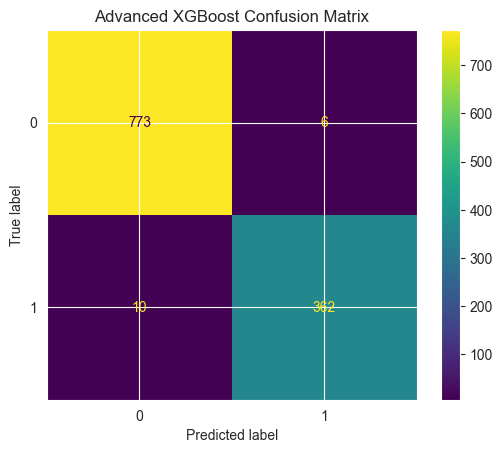

In [115]:
# =========================================================
# ADVANCED XGBOOST CONFUSION MATRIX
# =========================================================

advanced_xgb_cm = confusion_matrix(

    y_test_advanced,
    advanced_xgb_y_pred
)

advanced_xgb_disp = ConfusionMatrixDisplay(

    confusion_matrix=advanced_xgb_cm
)

advanced_xgb_disp.plot()

plt.title(

    "Advanced XGBoost Confusion Matrix"
)

plt.show()

In [116]:
# =========================================================
# ADVANCED XGBOOST PROBABILITIES
# =========================================================

advanced_xgb_y_proba = advanced_xgb_model.predict_proba(

    X_test_combined_advanced
)

advanced_xgb_spam_probabilities = (

    advanced_xgb_y_proba[:, 1]
)

advanced_xgb_spam_probabilities[:10]

array([0.00292259, 0.9948367 , 0.00603173, 0.9079609 , 0.99645764,
       0.00116882, 0.00153161, 0.99087256, 0.00401962, 0.00346459],
      dtype=float32)

In [117]:
# =========================================================
# SAVE ADVANCED XGBOOST MODEL
# =========================================================

advanced_xgb_model_path = (

    "../models/"
    "advanced_xgboost_model.pkl"
)

joblib.dump(

    advanced_xgb_model,
    advanced_xgb_model_path
)

print(

    f"Model saved to:\n{advanced_xgb_model_path}"
)

Model saved to:
../models/advanced_xgboost_model.pkl


In [122]:
# =========================================================
# CREATE FEATURE NAMES
# =========================================================

tfidf_feature_names = (

    advanced_vectorizer
    .get_feature_names_out()
)

manual_feature_names = [

    "url_count",

    "exclamation_count",

    "uppercase_ratio",

    "html_tag_count",

    "special_char_count",

    "spam_keyword_count"
]

all_feature_names = list(

    tfidf_feature_names
) + manual_feature_names

print(

    len(all_feature_names)
)

5006


In [123]:
# =========================================================
# FEATURE IMPORTANCE WITH REAL FEATURE NAMES
# =========================================================

xgb_feature_importance = pd.DataFrame({

    "feature_name": all_feature_names,

    "importance": advanced_xgb_model.feature_importances_
})

xgb_feature_importance = (

    xgb_feature_importance

    .sort_values(

        by="importance",

        ascending=False
    )
)

xgb_feature_importance.head(20)

,feature_name,importance
1795,fund,0.039592
5003,html_tag_count,0.036249
3666,remov,0.033506
4545,transact,0.032523
744,click,0.031242
5001,exclamation_count,0.026996
281,assist,0.023148
3358,post,0.017311
1915,group send,0.017106
3243,perl,0.015582


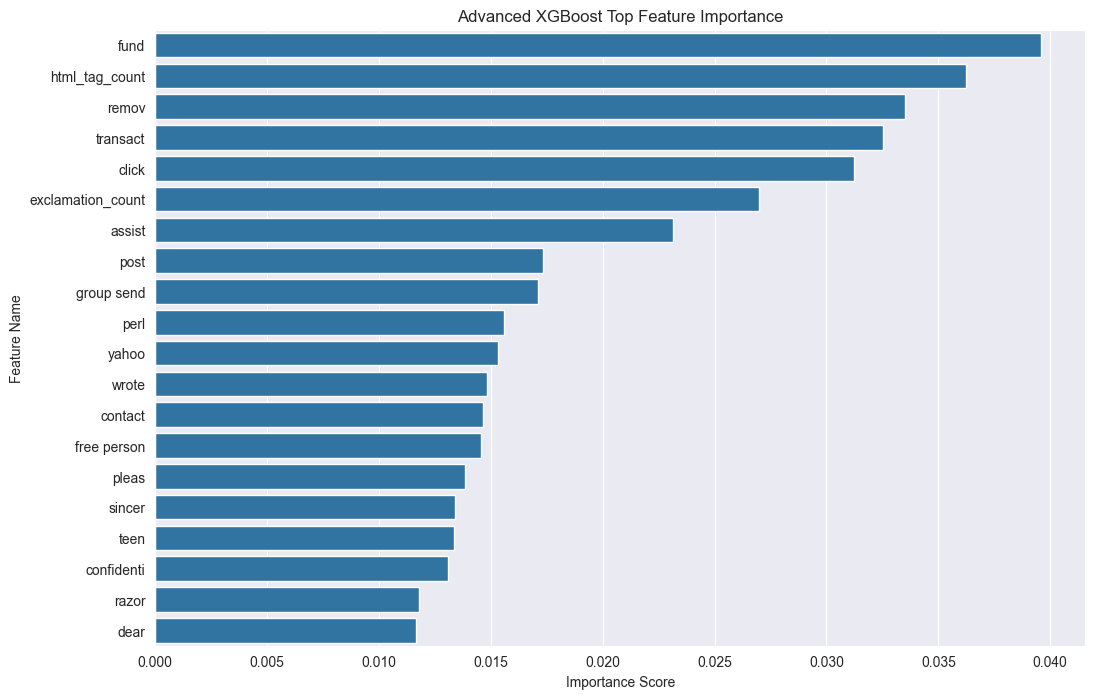

In [124]:
# =========================================================
# TOP FEATURE IMPORTANCE VISUALIZATION
# =========================================================

top_features = (

    xgb_feature_importance
    .head(20)
)

plt.figure(

    figsize=(12, 8)
)

sns.barplot(

    x=top_features["importance"],

    y=top_features["feature_name"]
)

plt.title(

    "Advanced XGBoost Top Feature Importance"
)

plt.xlabel(

    "Importance Score"
)

plt.ylabel(

    "Feature Name"
)

plt.show()

# =========================================================
# FINAL MODEL PERFORMANCE COMPARISON
# =========================================================

This section compares:

- Baseline machine learning models
- Advanced hybrid feature engineering models

Metrics compared:

- Accuracy
- Precision
- Recall
- F1 Score

Goal:
Select the best production-ready spam detection model.

In [125]:
# =========================================================
# MODEL PERFORMANCE COMPARISON
# =========================================================

comparison_df = pd.DataFrame({

    "Model": [

        "Naive Bayes",

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost",

        "Advanced Logistic Regression",

        "Advanced Random Forest",

        "Advanced XGBoost"
    ],

    "Accuracy": [

        accuracy,
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy,

        advanced_lr_accuracy,
        advanced_rf_accuracy,
        advanced_xgb_accuracy
    ],

    "Precision": [

        precision,
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision,

        advanced_lr_precision,
        advanced_rf_precision,
        advanced_xgb_precision
    ],

    "Recall": [

        recall,
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall,

        advanced_lr_recall,
        advanced_rf_recall,
        advanced_xgb_recall
    ],

    "F1 Score": [

        f1,
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1,

        advanced_lr_f1,
        advanced_rf_f1,
        advanced_xgb_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.986099,0.997207,0.959677,0.978082
1,Logistic Regression,0.981755,1.000000,0.943548,0.970954
2,Decision Tree,0.929626,0.907563,0.870968,0.888889
3,Random Forest,0.971329,1.000000,0.911290,0.953586
4,XGBoost,0.971329,0.985673,0.924731,0.954230
5,Advanced Logistic Regression,0.975673,0.991429,0.932796,0.961219
6,Advanced Random Forest,0.979149,0.994318,0.940860,0.966851
7,Advanced XGBoost,0.986099,0.983696,0.973118,0.978378


In [126]:
# =========================================================
# SORT MODELS BY F1 SCORE
# =========================================================

comparison_df = (

    comparison_df

    .sort_values(

        by="F1 Score",

        ascending=False
    )
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
7,Advanced XGBoost,0.986099,0.983696,0.973118,0.978378
0,Naive Bayes,0.986099,0.997207,0.959677,0.978082
1,Logistic Regression,0.981755,1.000000,0.943548,0.970954
6,Advanced Random Forest,0.979149,0.994318,0.940860,0.966851
5,Advanced Logistic Regression,0.975673,0.991429,0.932796,0.961219
4,XGBoost,0.971329,0.985673,0.924731,0.954230
3,Random Forest,0.971329,1.000000,0.911290,0.953586
2,Decision Tree,0.929626,0.907563,0.870968,0.888889


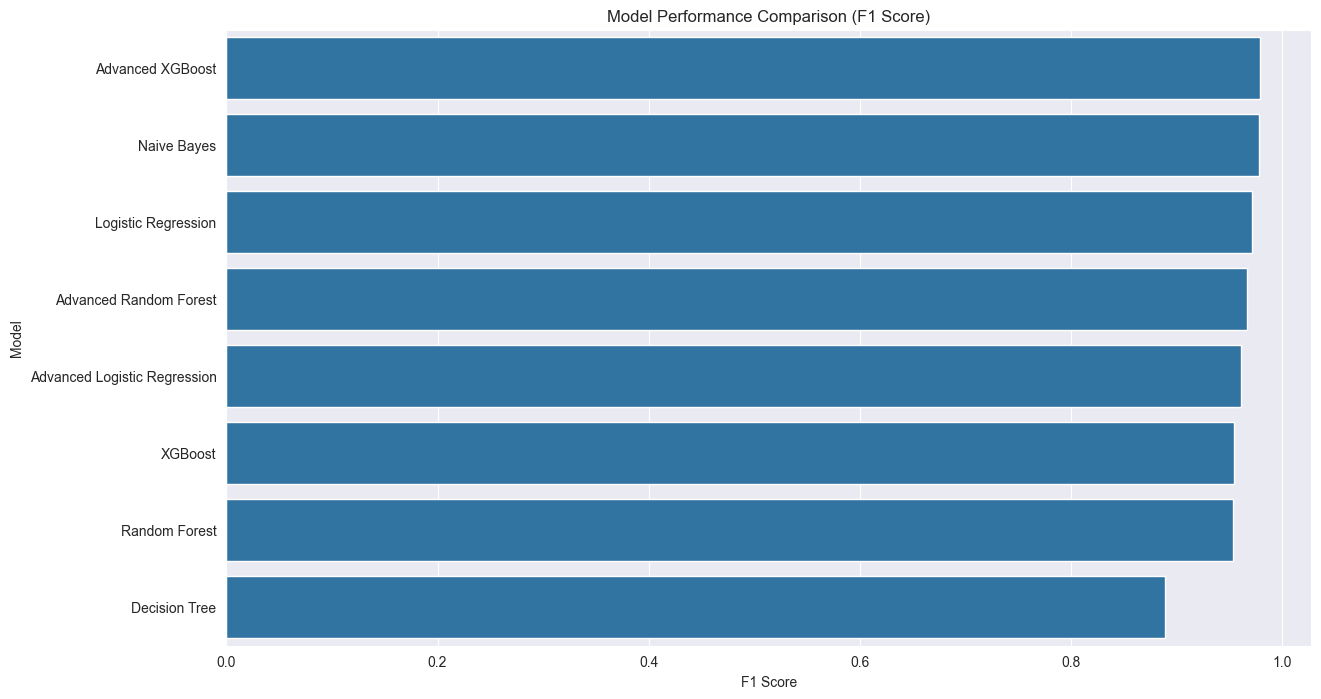

In [127]:
# =========================================================
# MODEL PERFORMANCE VISUALIZATION
# =========================================================

plt.figure(

    figsize=(14, 8)
)

sns.barplot(

    data=comparison_df,

    x="F1 Score",

    y="Model"
)

plt.title(

    "Model Performance Comparison (F1 Score)"
)

plt.xlabel(

    "F1 Score"
)

plt.ylabel(

    "Model"
)

plt.show()